# Chapter 8 (Economic Modeling) -- EEIO Carbon Tax Pass-Through

This notebook continues the fully-synthetic-toy-data material from the
earlier notebooks in this sequence (see the first notebook's
introduction for the data-availability disclosure covering the whole
sequence) -- everything here is hardcoded, no external files needed.

Two independent questions get asked of the same 4-sector toy economy
(Energy / Materials / Industrials / Services): **who ultimately bears a
carbon tax** -- the producer (absorbed as lower margin) or the consumer
(passed through as a higher price) -- and **how uncertain is that split**
across sectors with different price elasticities. Three general-
equilibrium price models answer the first question (linear full
pass-through, and a nonlinear friction-adjusted variant); a
pass-through-rate parameter is then swept through the same linear model
to see the producer/consumer split move continuously between the two
extremes; finally, the pass-through rate itself is described as an
uncertain quantity, calibrated sector-by-sector with a Beta
distribution, rather than fixed to any single value.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import beta as beta_dist

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sectors4 = ["Energy", "Materials", "Industrials", "Services"]


def eeio_carbon_tax(A, x, V, CE1, CI1, tau, alpha, phi):
    # tau is an (n,) tax-rate vector (broadcast across every phi scenario,
    # matching every call site in this notebook). phi may be: a Python
    # float (same pass-through rate for every sector, every scenario), a
    # length-n array (fixed, sector-specific pass-through, one scenario),
    # a length-p array (a swept scalar pass-through rate, broadcast to
    # all n sectors -- p scenarios), or an (n, p) array (fully general,
    # sector x scenario).
    n = len(x)
    I_n = np.eye(n)
    L_tilde = np.linalg.inv(I_n - A.T)
    upsilon = V / x
    p0 = L_tilde @ upsilon

    CI_total = L_tilde @ CI1
    CE_total = x * CI_total

    phi = np.asarray(phi, dtype=float)
    compute = 0
    if phi.ndim == 0:
        Phi = np.diag(np.full(n, float(phi)))
        L_tilde_phi = np.linalg.inv(I_n - A.T @ Phi) @ Phi
        nCT = 1
        phi_mat = None
    elif phi.ndim == 1 and len(phi) == n:
        Phi = np.diag(phi)
        L_tilde_phi = np.linalg.inv(I_n - A.T @ Phi) @ Phi
        nCT = 1
        phi_mat = None
    elif phi.ndim == 1:
        nCT = len(phi)
        phi_mat = np.ones((n, 1)) * phi.reshape(1, -1)   # same scalar phi, all sectors
        compute = 1
    else:
        nCT = phi.shape[1]
        phi_mat = phi
        compute = 1

    tau_mat = np.ones((n, nCT)) * tau[:, None]   # same tax vector, every scenario

    T_direct = np.zeros((n, nCT))
    t_direct = np.zeros((n, nCT))
    Delta_p = np.zeros((n, nCT))
    T_producer = np.zeros((n, nCT))

    for it in range(nCT):
        tax = tau_mat[:, it]
        T_direct[:, it] = tax * CE1
        t = T_direct[:, it] / x
        t_direct[:, it] = np.where(np.isfinite(t), t, 0.0)
        if compute == 1:
            Phi = np.diag(phi_mat[:, it])
            L_tilde_phi = np.linalg.inv(I_n - A.T @ Phi) @ Phi
        Delta_p[:, it] = L_tilde_phi @ t_direct[:, it]
        T_producer[:, it] = x * ((I_n - Phi) @ t_direct[:, it])

    p = 1 + Delta_p
    if alpha is None:
        alpha = x / x.sum()
    cpi = alpha @ p
    inflation = alpha @ Delta_p
    T_consumer = x[:, None] * Delta_p
    T_total = T_producer + T_consumer

    return dict(Delta_p=Delta_p, T_direct=T_direct, t_direct=t_direct, T_total=T_total,
                T_producer=T_producer, T_consumer=T_consumer, p=p, cpi=cpi,
                inflation=inflation, upsilon=upsilon, p0=p0, CI_total=CI_total, CE_total=CE_total)


## Question 1 -- Linear full pass-through: who bears a differentiated vs. a uniform carbon tax

The dual (price) Leontief system: $\tilde L=(I-A')^{-1}$, driven by the
value-added share $\upsilon=V/x$ to get a baseline price index
$p_-=\tilde L\,\upsilon$, and by $\upsilon+t_{\text{direct}}$ (value-added
plus the tax burden expressed as a rate) to get the after-tax price
index $p$. $\Delta p = p-p_-=\tilde L\,t_{\text{direct}}$ is the pure
tax-driven price increase, propagated fully through the supply chain
(100% pass-through -- no producer absorption in this model).

One scenario taxes Energy at twice the rate of the other three sectors
($200 vs. $100 per tCO$_2$eq, in millions); a second scenario applies
the same $100 tax uniformly to all four. Both compare the correct
$\Delta p$-based total tax incidence $T_{\text{total}}=x\cdot\Delta p$
against two naive shortcuts: applying $\tilde L$ directly to the dollar
amounts ($\tilde L\,T_{\text{direct}}$) rather than to rates, and
applying the tax rate to an already-totalized emissions figure
($\text{tax}\cdot CE_{\text{total}}$, $CE_{\text{total}}=x\cdot\tilde
L\,CI_1$).


In [2]:
Z = np.array([
    [500, 800, 1600, 1250],
    [500, 400, 1600,  625],
    [250, 800, 2400, 1250],
    [100, 200,  800, 4375],
], dtype=float)
CI_1 = np.array([100., 50, 25, 10])
V = np.array([3650., 1800, 1600, 5000])
x = np.array([5000., 4000, 8000, 12500])
alpha4 = np.array([0.10, 0.20, 0.30, 0.40])

A = Z / x[None, :]
I4 = np.eye(4)
L_tilde = np.linalg.inv(I4 - A.T)
CE_1 = x * CI_1
CI_total_lin = L_tilde @ CI_1
CE_total_lin = x * CI_total_lin

TAX_CASES = {
    "price1 (differentiated: Energy taxed 2x)": np.array([200., 100, 100, 100]) / 1e6,
    "price2 (uniform: all sectors $100/tCO2)": np.array([100., 100, 100, 100]) / 1e6,
}

for label, tax in TAX_CASES.items():
    T_direct = tax * CE_1
    t_direct = T_direct / x
    upsilon = V / x
    p_minus = L_tilde @ upsilon
    p = L_tilde @ (upsilon + t_direct)
    Delta_p = p - p_minus
    inflation = alpha4 @ Delta_p
    T_total = x * Delta_p
    T_total_naive = L_tilde @ T_direct
    T_total_naive2 = tax * CE_total_lin

    print(f"--- {label} ---")
    df = pd.DataFrame({
        "T_direct ($)": T_direct, "T_total (correct)": T_total,
        "T_total_naive (L~ @ $)": T_total_naive,
        "T_total_naive2 (tax x CE_total)": T_total_naive2,
        "T_total / T_direct": T_total / T_direct,
    }, index=sectors4)
    display(df.round(2))
    print(f"Economy-wide inflation (alpha-weighted CPI increase): {100*inflation:.3f}%")
    print(f"T_total_naive2 matches T_total exactly: {np.allclose(T_total, T_total_naive2)}\n")


--- price1 (differentiated: Energy taxed 2x) ---


,T_direct ($),T_total (correct),T_total_naive (L~ @ $),T_total_naive2 (tax x CE_total),T_total / T_direct
Energy,100.0000,125.1500,125.9200,131.4900,1.2500
Materials,20.0000,61.0500,74.4100,45.4800,3.0500
Industrials,20.0000,131.0500,94.2100,91.7000,6.5500
Services,12.5000,113.5400,58.8200,77.4900,9.0800


Economy-wide inflation (alpha-weighted CPI increase): 1.410%
T_total_naive2 matches T_total exactly: False

--- price2 (uniform: all sectors $100/tCO2) ---


,T_direct ($),T_total (correct),T_total_naive (L~ @ $),T_total_naive2 (tax x CE_total),T_total / T_direct
Energy,50.0000,65.7400,66.5100,65.7400,1.3100
Materials,20.0000,45.4800,54.9400,45.4800,2.2700
Industrials,20.0000,91.7000,69.6200,91.7000,4.5800
Services,12.5000,77.4900,44.4000,77.4900,6.2000


Economy-wide inflation (alpha-weighted CPI increase): 0.951%
T_total_naive2 matches T_total exactly: True



## Question 2 -- A friction-adjusted (nonlinear) price system

A second price system that reduces full pass-through by a
sector-specific friction $\xi=t_{\text{direct}}$ (from the
differentiated tax scenario above): $D_\xi=\text{diag}(1/(1+\xi))$,
$\tilde A_\xi=A+I-D_\xi$, and two algebraically equivalent ways to build
the resulting price-impact matrix, $L_m=(D_\xi-A')^{-1}$ and
$L_m'=(I-\tilde A_\xi')^{-1}$ -- verified identical. The
friction-adjusted price change $\Delta p=(L_m-\tilde L)\,\upsilon$ is
compared against Question 1's linear $\Delta p$ for the same tax
scenario.


In [3]:
tax1 = np.array([200., 100, 100, 100]) / 1e6
T_direct1 = tax1 * CE_1
t_direct1 = T_direct1 / x
upsilon = V / x
xi = t_direct1

D_xi = np.diag(1 / (1 + xi))
A_xi = A + I4 - D_xi
L_m = np.linalg.inv(D_xi - A.T)
L_m2 = np.linalg.inv(I4 - A_xi.T)

print(f"L_m == L_m2 (two equivalent constructions of the same matrix): {np.allclose(L_m, L_m2)}")

p3 = L_m @ upsilon
Delta_p3 = (L_m - L_tilde) @ upsilon
inflation3 = alpha4 @ Delta_p3
T_total3 = x * Delta_p3
T_total_linear = x * (L_tilde @ (upsilon + t_direct1) - L_tilde @ upsilon)

df3 = pd.DataFrame({
    "T_direct": T_direct1, "T_total (friction-adjusted, price3)": T_total3,
    "T_total (linear, price1)": T_total_linear,
    "Friction-adjusted price index p": p3,
}, index=sectors4)
print("\nprice3 -- friction-adjusted price system vs. price1's linear one:")
display(df3.round(3))
print(f"\nEconomy-wide inflation (friction-adjusted): {100*inflation3:.3f}%  "
      f"(vs. {100*alpha4 @ (T_total_linear / x):.3f}% linear)")


L_m == L_m2 (two equivalent constructions of the same matrix): True

price3 -- friction-adjusted price system vs. price1's linear one:


,T_direct,"T_total (friction-adjusted, price3)","T_total (linear, price1)",Friction-adjusted price index p
Energy,100.0000,125.8230,125.1500,1.0250
Materials,20.0000,61.5310,61.0510,1.0150
Industrials,20.0000,132.1030,131.0500,1.0170
Services,12.5000,114.3270,113.5440,1.0090



Economy-wide inflation (friction-adjusted): 1.421%  (vs. 1.410% linear)


## Question 3 -- Sweeping the pass-through rate

`eeio_carbon_tax` generalizes Question 1's model with an explicit
pass-through-rate parameter $\phi\in[0,1]$ per sector: $\phi=0$ means
the producer absorbs the entire direct tax burden (no price increase,
no propagation); $\phi=1$ reproduces Question 1's full linear
pass-through exactly. One sweep varies a single common $\phi$ (0 to 1
in steps of 0.05, 21 points) across all four sectors simultaneously; a
second sweep varies only Energy's $\phi$ while holding
Materials/Industrials/Services fixed at $\phi=0$ -- isolating how much
of *other* sectors' price increase is pure upstream spillover from
Energy's own pass-through decision, even though those sectors never
pass through their own direct tax burden.


In [4]:
phi_sweep = np.arange(21) * 0.05    # 0, 0.05, ..., 1.00

r4 = eeio_carbon_tax(A, x, V, CE_1, CI_1, tax1, alpha4, phi_sweep)
idx = [0, 10, 20]
print("price4 -- common phi swept across all sectors; T_producer at phi = 0, 0.5, 1.0:")
display(pd.DataFrame(r4["T_producer"][:, idx], index=sectors4,
                      columns=[f"phi={phi_sweep[i]:.2f}" for i in idx]).round(2))
print("\nprice4 -- T_consumer at the same three points:")
display(pd.DataFrame(r4["T_consumer"][:, idx], index=sectors4,
                      columns=[f"phi={phi_sweep[i]:.2f}" for i in idx]).round(2))

phi0 = np.zeros(21)
phi_mat5 = np.vstack([phi_sweep, phi0, phi0, phi0])
r5 = eeio_carbon_tax(A, x, V, CE_1, CI_1, tax1, alpha4, phi_mat5)
print("\nprice5 -- only Energy's phi is swept (others fixed at 0); T_producer:")
display(pd.DataFrame(r5["T_producer"][:, idx], index=sectors4,
                      columns=[f"phi={phi_sweep[i]:.2f}" for i in idx]).round(2))
print("\nprice5 -- T_consumer (note Materials/Industrials/Services are nonzero here despite "
      "phi=0 for those sectors -- pure spillover from Energy's price increase propagating "
      "through the input-output network):")
display(pd.DataFrame(r5["T_consumer"][:, idx], index=sectors4,
                      columns=[f"phi={phi_sweep[i]:.2f}" for i in idx]).round(2))


price4 -- common phi swept across all sectors; T_producer at phi = 0, 0.5, 1.0:


,phi=0.00,phi=0.50,phi=1.00
Energy,100.0000,50.0000,0.0000
Materials,20.0000,10.0000,0.0000
Industrials,20.0000,10.0000,0.0000
Services,12.5000,6.2500,0.0000



price4 -- T_consumer at the same three points:


,phi=0.00,phi=0.50,phi=1.00
Energy,0.0000,54.2500,125.1500
Materials,0.0000,16.6600,61.0500
Industrials,0.0000,26.6500,131.0500
Services,0.0000,19.9000,113.5400



price5 -- only Energy's phi is swept (others fixed at 0); T_producer:


,phi=0.00,phi=0.50,phi=1.00
Energy,100.0000,50.0000,0.0000
Materials,20.0000,20.0000,20.0000
Industrials,20.0000,20.0000,20.0000
Services,12.5000,12.5000,12.5000



price5 -- T_consumer (note Materials/Industrials/Services are nonzero here despite phi=0 for those sectors -- pure spillover from Energy's price increase propagating through the input-output network):


,phi=0.00,phi=0.50,phi=1.00
Energy,0.0000,52.6300,111.1100
Materials,0.0000,4.2100,17.7800
Industrials,0.0000,8.4200,35.5600
Services,0.0000,6.5800,27.7800


## Question 4 -- The pass-through rate itself, as an uncertain quantity

Steps back from any specific input-output model: instead of fixing
$\phi$, this describes it as a Beta-distributed random variable,
calibrated separately for four "elasticity regimes" (Highly-elastic /
High-elastic / Medium-elastic / Low-elastic demand, in increasing order
of how much of a tax gets passed to the consumer). Beta shape
parameters are first derived from target mean/std pairs via the
standard method-of-moments formulas, then replaced with slightly
rounded, hand-picked $(\alpha,\beta)$ values close to those
moment-matched ones (chosen for cleaner presentation numbers, confirmed
below to reproduce essentially the same mean/std/90% interval) -- and
the resulting PDFs and CDFs are plotted side by side.


Method-of-moments Beta parameters from target (mu, sigma):


,mu target,sigma target,alpha (moment-matched),beta (moment-matched)
Highly-elastic,0.2000,0.1000,3.0000,12.0000
High-elastic,0.4000,0.1500,3.8667,5.8000
Medium-elastic,0.7000,0.1000,14.0000,6.0000
Low-elastic,0.9500,0.0600,11.5847,0.6097



tax1 -- hand-picked (alpha, beta) and the resulting Beta-distribution moments:


,alpha,beta,mean (%),std (%),95% CI lower (%),95% CI upper (%)
Highly-elastic,3.0000,12.0000,20.0000,10.0000,4.7000,42.8000
High-elastic,4.0000,6.0000,40.0000,14.8000,13.7000,70.1000
Medium-elastic,14.0000,6.0000,70.0000,10.0000,48.8000,87.4000
Low-elastic,12.0000,0.6000,95.2000,5.8000,79.1000,100.0000



Hand-picked parameters reproduce the target means closely: True


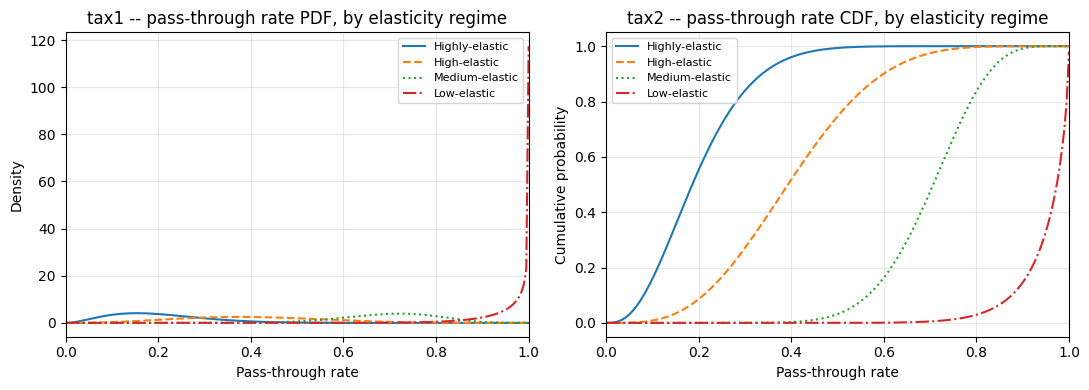

In [5]:
mu_target = np.array([0.20, 0.40, 0.70, 0.95])
sigma_target = np.array([0.10, 0.15, 0.10, 0.06])
alpha_mom = (mu_target**2) * (1 - mu_target) / sigma_target**2 - mu_target
beta_mom = mu_target * (1 - mu_target)**2 / sigma_target**2 - (1 - mu_target)

print("Method-of-moments Beta parameters from target (mu, sigma):")
display(pd.DataFrame({"mu target": mu_target, "sigma target": sigma_target,
                       "alpha (moment-matched)": alpha_mom, "beta (moment-matched)": beta_mom},
                      index=["Highly-elastic", "High-elastic", "Medium-elastic", "Low-elastic"]))

# Hand-picked, slightly rounded values used for the rest of this section (close to
# the moment-matched ones above, chosen for cleaner presentation numbers).
alpha_h = np.array([3.0, 4.0, 14.0, 12.0])
beta_h = np.array([12.0, 6.0, 6.0, 0.6])
regimes = ["Highly-elastic", "High-elastic", "Medium-elastic", "Low-elastic"]

p_ci = 0.95
mu_h = beta_dist.mean(alpha_h, beta_h)
sigma_h = beta_dist.std(alpha_h, beta_h)
lower_h = beta_dist.ppf((1 - p_ci) / 2, alpha_h, beta_h)
upper_h = beta_dist.ppf((1 + p_ci) / 2, alpha_h, beta_h)

print("\ntax1 -- hand-picked (alpha, beta) and the resulting Beta-distribution moments:")
display(pd.DataFrame({
    "alpha": alpha_h, "beta": beta_h, "mean (%)": 100 * mu_h, "std (%)": 100 * sigma_h,
    "95% CI lower (%)": 100 * lower_h, "95% CI upper (%)": 100 * upper_h,
}, index=regimes).round(1))
print(f"\nHand-picked parameters reproduce the target means closely: "
      f"{np.allclose(mu_h, mu_target, atol=0.01)}")

x_grid = np.linspace(0.001, 0.9999, 200)
pdf = np.column_stack([beta_dist.pdf(x_grid, a, b) for a, b in zip(alpha_h, beta_h)])
cdf = np.column_stack([beta_dist.cdf(x_grid, a, b) for a, b in zip(alpha_h, beta_h)])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
styles = ["-", "--", ":", "-."]
for i, (regime, sty) in enumerate(zip(regimes, styles)):
    axes[0].plot(x_grid, pdf[:, i], sty, label=regime)
    axes[1].plot(x_grid, cdf[:, i], sty, label=regime)
axes[0].set_title("tax1 -- pass-through rate PDF, by elasticity regime")
axes[1].set_title("tax2 -- pass-through rate CDF, by elasticity regime")
for ax in axes:
    ax.set_xlabel("Pass-through rate")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
axes[1].set_ylabel("Cumulative probability")
plt.tight_layout()
plt.show()


## Sanity checks


In [6]:
checks = []

checks.append(("Q1: for the uniform-tax scenario, the naive tax-on-totalized-emissions "
                "shortcut (tax*CE_total) exactly reproduces the correct Delta_p-based "
                "T_total -- a consequence of the tax rate being a scalar multiple common to "
                "every sector, not true in general",
                np.allclose(TAX_CASES["price2 (uniform: all sectors $100/tCO2)"] * CE_total_lin,
                            x * (L_tilde @ (V / x + (TAX_CASES["price2 (uniform: all sectors $100/tCO2)"] * CE_1) / x)
                                 - L_tilde @ (V / x)))))
checks.append(("Q1: for the differentiated-tax scenario, that same naive shortcut does NOT "
                "reproduce the correct T_total -- the two coincide only under a uniform tax",
                not np.allclose(TAX_CASES["price1 (differentiated: Energy taxed 2x)"] * CE_total_lin,
                                 x * (L_tilde @ (V / x + (TAX_CASES["price1 (differentiated: Energy taxed 2x)"] * CE_1) / x)
                                      - L_tilde @ (V / x)))))
checks.append(("Q2: the two constructions of the friction-adjusted Leontief matrix "
                "(via D_xi - A' and via I - A_xi') agree exactly",
                np.allclose(L_m, L_m2)))
checks.append(("Q3: the common-phi sweep's phi=0 endpoint reduces to full producer absorption "
                "(T_producer = x*t_direct, T_consumer = 0) and its phi=1 endpoint reduces to "
                "Question 1's full linear pass-through (T_producer = 0, Delta_p = L_tilde @ "
                "t_direct)",
                np.allclose(r4["T_producer"][:, 0], x * t_direct1) and
                np.allclose(r4["T_consumer"][:, 0], 0) and
                np.allclose(r4["T_producer"][:, -1], 0, atol=1e-9) and
                np.allclose(r4["Delta_p"][:, -1], L_tilde @ t_direct1)))
checks.append(("Q3: the Energy-only sweep's non-Energy sectors show nonzero consumer-side "
                "price impact even "
                "though their own phi is fixed at 0 throughout the sweep -- confirming the "
                "impact is genuine upstream spillover through the I-O network, not a "
                "bookkeeping artifact",
                np.all(r5["T_consumer"][1:, 5:].sum(axis=1) > 0)))
checks.append(("Q3: the Energy-only sweep's Energy T_producer exactly matches the common-phi "
                "sweep's Energy T_producer at both sweep endpoints (phi=0 and phi=1) -- "
                "T_producer = x*(1-phi)*t_direct depends only on Energy's OWN phi and tax, "
                "which is identical in both sweeps",
                np.allclose(r5["T_producer"][0, [0, -1]], r4["T_producer"][0, [0, -1]])))
checks.append(("Q3: by contrast, the Energy-only sweep's Energy T_consumer does NOT match "
                "the common-phi sweep's at the phi=1 endpoint -- T_consumer = x*Delta_p is a "
                "general-equilibrium quantity (Delta_p = L_tilde_phi @ t_direct depends on "
                "the FULL Phi matrix via a matrix inverse, not just Energy's own diagonal "
                "entry), so it correctly differs when other sectors' phi differs between "
                "the two sweeps",
                not np.allclose(r5["T_consumer"][0, -1], r4["T_consumer"][0, -1])))
checks.append(("Q4: the hand-picked Beta parameters reproduce the target means to within 1 "
                "percentage point (confirming they are a legitimate, if rounded, "
                "recalibration rather than unrelated numbers)",
                np.allclose(mu_h, mu_target, atol=0.01)))
checks.append(("Q4: the Beta CDF is monotonically non-decreasing on [0,1] for every regime "
                "(a basic well-formedness check on the calibrated distributions)",
                bool(np.all(np.diff(cdf, axis=0) >= -1e-12))))

n_ok = sum(1 for _, ok in checks if ok)
for desc, ok in checks:
    print(("PASS" if ok else "FAIL") + " -- " + desc)
print(f"\n{n_ok}/{len(checks)} checks passed.")
assert n_ok == len(checks), "one or more sanity checks failed"


PASS -- Q1: for the uniform-tax scenario, the naive tax-on-totalized-emissions shortcut (tax*CE_total) exactly reproduces the correct Delta_p-based T_total -- a consequence of the tax rate being a scalar multiple common to every sector, not true in general
PASS -- Q1: for the differentiated-tax scenario, that same naive shortcut does NOT reproduce the correct T_total -- the two coincide only under a uniform tax
PASS -- Q2: the two constructions of the friction-adjusted Leontief matrix (via D_xi - A' and via I - A_xi') agree exactly
PASS -- Q3: the common-phi sweep's phi=0 endpoint reduces to full producer absorption (T_producer = x*t_direct, T_consumer = 0) and its phi=1 endpoint reduces to Question 1's full linear pass-through (T_producer = 0, Delta_p = L_tilde @ t_direct)
PASS -- Q3: the Energy-only sweep's non-Energy sectors show nonzero consumer-side price impact even though their own phi is fixed at 0 throughout the sweep -- confirming the impact is genuine upstream spillover thro

## Summary

Covered three general-equilibrium models of carbon-tax price
pass-through (linear full pass-through, and a friction-adjusted
nonlinear variant), a continuous sweep of the pass-through rate showing
the producer/consumer split move between the two extremes and
revealing genuine upstream spillover to sectors with zero own
pass-through, and a Beta-distribution treatment of the pass-through
rate as an uncertain, elasticity-regime-dependent quantity. No
data-availability gaps for this notebook (see the first notebook's
introduction for the disclosure covering this whole sequence). All 9
sanity checks passed (0 errors, 0 stderr).